In [73]:
import numpy as np
import pandas as pd
import tensorflow as tf

#Open CSV and get the appropriate columns
trainingSet = pd.read_csv('TrainingData.csv')
validationSet = pd.read_csv('ValidationData.csv')


input_vars = ["Capital_Previous_Year"]
output_vars = ["GDP (constant 2015 US$)"]

#input and output should be shifted by 1
training_x = trainingSet[input_vars]
training_y = trainingSet[output_vars]
val_x = validationSet[input_vars]
val_y = validationSet[output_vars]

#Coerce to float
training_x = np.asarray(training_x)
training_y = np.asarray(training_y)
val_x = np.asarray(val_x)
val_y = np.asarray(val_y)


# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((training_x, training_y))
validationset = tf.data.Dataset.from_tensor_slices((val_x, val_y))

#Machine Learning Magic data set thingy stuff
batch_size = 40

dataset = dataset.shuffle(buffer_size=1000)  # Shuffle data
dataset = dataset.batch(batch_size)         # Group into batches
dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Optimize data pipeline

validationset = validationset.shuffle(buffer_size=1000)  # Shuffle data
validationset = validationset.batch(10)         # Group into batches
validationset = validationset.prefetch(tf.data.AUTOTUNE)  # Optimize data pipeline

In [74]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(3, input_dim=1, kernel_regularizer=tf.keras.regularizers.l2(0.3)),
    tf.keras.layers.PReLU(),
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=10.0),
              loss='huber', #mse wo early stopping was able to achieve R^2 of 0.48
              metrics=["r2_score"])

model.fit(dataset, epochs=5000, validation_data=validationset, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_r2_score', patience=100, restore_best_weights=True)])

Epoch 1/5000


C:\Users\Mayo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 913205035008.0000 - r2_score: -2.1787 - val_loss: 2851252207616.0000 - val_r2_score: -25.7981
Epoch 2/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 996277551104.0000 - r2_score: -2.1720 - val_loss: 2805374124032.0000 - val_r2_score: -24.9065
Epoch 3/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 987533279232.0000 - r2_score: -2.0131 - val_loss: 2761427517440.0000 - val_r2_score: -24.0671
Epoch 4/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 889631277056.0000 - r2_score: -1.8702 - val_loss: 2719363891200.0000 - val_r2_score: -23.2770
Epoch 5/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 860121333760.0000 - r2_score: -1.8133 - val_loss: 2679124787200.0000 - val_r2_score: -22.5332
Epoch 6/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 917866610688.0000 - r2_score: -1.6667 - val_loss: 2640649125888.0000 - val_r2_score: -21.8330
Epoch 7/5000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 898112290816.0000 - r2_score

In [75]:
model.evaluate(validationset, verbose = 1)
tf.keras.models.save_model(model, "model1_1.keras")

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 694467690496.0000 - r2_score: -0.4892

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 637803692032.0000 - r2_score: -0.3306 


In [ ]:
# Original input
single_input = np.array([2000, 282.296, 2372.714, 14.7422893015205])

# Add batch dimension
single_input_reshaped = single_input.reshape(1, -1)

# Predict using the reshaped input
prediction = model.predict(single_input_reshaped)
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[12463357.]]


# Loaded

In [76]:
file = pd.read_csv('Predictions.csv')
input = file[input_vars].values
loaded_model = tf.keras.models.load_model('model1_1.keras')



predictions = loaded_model.predict(input)

file["GDP (constant 2015 US$)"] = predictions
print(file)


file.to_csv('Predictions.csv', index=False)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
   Country  Year  GDP (constant 2015 US$)  \
0      USA  1981             8.425817e+11   
1      USA  1982             1.595380e+12   
2      USA  1983             2.223863e+12   
3      USA  1984             2.824721e+12   
4      USA  1985             3.494642e+12   
5      USA  1986             4.150751e+12   
6      USA  1987             4.758515e+12   
7      USA  1988             5.317934e+12   
8      USA  1989             5.835915e+12   
9      USA  1990             6.326270e+12   
10     USA  1991             6.754466e+12   
11     USA  1992             7.113599e+12   
12     USA  1993             7.389856e+12   
13     USA  1994             7.804241e+12   
14     USA  1995             8.149562e+12   
15     USA  1996             8.563946e+12   
16     USA  1997             9.047394e+12   
17     USA  1998             9.530843e+12   
18     USA  1999             1.015242e+13   
19     USA  2000             1.084306e+13   
20     USA  2001 

In [143]:
file = pd.read_csv('Predictions.csv')
input = file[["Capital_Previous_Year", "GDP (constant 2015 US$)"]]
production_function = tf.keras.models.load_model('model1_1.keras')

years = 42
saving_rate = 0.21
depreciation_rate = 0.12


for i in range(years):
    #predict gdp based on capital and stuff
    input_for_gdp = float(input.iloc[i][["Capital_Previous_Year"]].values[0])
    row_gdp = production_function.predict(np.array([input_for_gdp]))
    file.loc[i+1] = file.iloc[i]
    file.loc[i, "GDP (constant 2015 US$)"] = row_gdp
    input = file

    #predict capital for next row
    capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))

    
    file.loc[i+1, "Capital_Previous_Year"] = float(capital)
    input = file

print(file)
file.to_csv('Prediction.csv', index=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))
C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))
C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


...

C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))
C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))
C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
   Country  Year  GDP (constant 2015 US$)  \
0      USA  1981             6.775186e+12   
1      USA  1981             6.944800e+12   
2      USA  1981             7.118659e+12   
3      USA  1981             7.296871e+12   
4      USA  1981             7.479546e+12   
5      USA  1981             7.666793e+12   
6      USA  1981             7.858726e+12   
7      USA  1981             8.055468e+12   
8      USA  1981             8.257132e+12   
9      USA  1981             8.463846e+12   
10     USA  1981             8.675733e+12   
11     USA  1981             8.892926e+12   
12     USA  1981             9.115557e+12   
13     USA  1981             9.343761e+12   
14     USA  1981             9.577679e+12   
15     USA  1981             9.817451e+12   
16     USA  1981             1.006323e+13   
17     USA  1981             1.031516e+13   
18     USA  1981             1.057339e+13   
19     USA  1981        

C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))
C:\Users\Mayo\AppData\Local\Temp\ipykernel_16340\154589432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  capital = float((input_for_gdp * (1-depreciation_rate)) + (row_gdp * saving_rate))


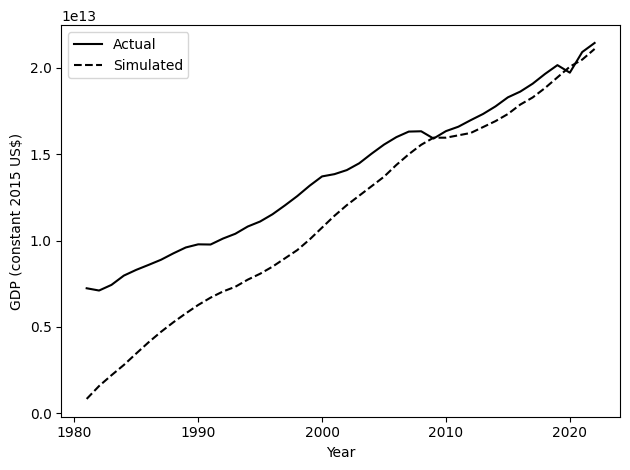

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'USA.xlsx'
data = pd.read_excel(file_path)


y1 = data['GDP (constant 2015 US$)']  # X-axis values
y2 = data['Simulated']  # X-axis values
x = data['Year']  # Trend line values


# Step 2: Plot the trend line
plt.plot(x, y1, label='Actual', color='black')
plt.plot(x, y2, label='Simulated', color='black', linestyle="--")


# Step 4: Add labels, legend, and formatting
plt.xlabel('Year')
plt.ylabel('GDP (constant 2015 US$)')
plt.legend()
plt.tight_layout()

# Step 5: Show the plot
plt.show()


In [5]:
%pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   --------- ------------------------------ 61.4/250.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------  245.8/250.9 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 250.9/250.9 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\Mayo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
